# Variational DA with a Learned Inverse Observation Operator — PyTorch

Port of Frerix et al. 2021 ([arXiv:2102.11192](https://arxiv.org/abs/2102.11192)) from JAX/Flax to PyTorch.

**Sections**
1. Lorenz96: system, inverse-observation CNN, variational DA (obs-space / physics-space / hybrid).
2. Experiment A — three Gaussian noise levels, basic DA performance (no background term).
3. Experiment B — full 4D-Var on Lorenz96 with background covariance $B$ and obs covariance $R$. Tests all four combinations of {observation opt, hybrid opt} × {baseline init, inverse init}, with presentation-ready forecast plots.

Designed for Colab GPU. Defaults are small enough to run in a few minutes — scale up for real experiments.


In [1]:
# Colab setup
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import sys, subprocess
def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

# torchdiffeq is optional — we use a hand-written RK4 below. Uncomment if you want adaptive solvers.
# pip('torchdiffeq')

In [2]:
import math
from functools import partial
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
np.random.seed(0)
print(f'device={device}, torch={torch.__version__}')

device=cuda, torch=2.11.0+cu128


### Disk cache (Google Drive)

Survives runtime resets. Set `FORCE_RETRAIN = True` to ignore the cache and regenerate. To clear: delete files in `/content/drive/MyDrive/invobs_cache/`.

In [3]:
import os

FORCE_RETRAIN = False
CACHE_DIR = '/content/drive/MyDrive/invobs_cache'

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
os.makedirs(CACHE_DIR, exist_ok=True)


def cache_path(name):
    return os.path.join(CACHE_DIR, name)


def save_cache(obj, name):
    torch.save(obj, cache_path(name))
    print(f'  [cache] wrote {name}')


def load_cache(name):
    p = cache_path(name)
    if FORCE_RETRAIN or not os.path.exists(p):
        return None
    print(f'  [cache] loaded {name}')
    return torch.load(p, map_location=device, weights_only=False)


print(f'Cache dir: {CACHE_DIR}')
print(f'Existing cache files: {sorted(os.listdir(CACHE_DIR)) if os.path.isdir(CACHE_DIR) else []}')

Mounted at /content/drive
Cache dir: /content/drive/MyDrive/invobs_cache
Existing cache files: ['l96_4dvar_combos_N16_T10.pt', 'l96_corr.pt', 'l96_expA_4combo_N100_T10.pt', 'l96_expA_4combo_N160_T10.pt', 'l96_inverter_sigma0.0.pt', 'l96_inverter_sigma0.1.pt', 'l96_inverter_sigma0.5.pt', 'l96_inverter_sigma1.0.pt', 'l96_noise_results.pt']


---
## 1. Lorenz96

$\dot x_k = -x_{k-1}(x_{k-2} - x_{k+1}) - x_k + F$ with periodic BCs. Observation operator: subsample every `observe_every` grid points.

In [4]:
def rk4_step(rhs, x, dt):
    k1 = rhs(x)
    k2 = rhs(x + 0.5 * dt * k1)
    k3 = rhs(x + 0.5 * dt * k2)
    k4 = rhs(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


class Lorenz96:
    def __init__(self, grid_size=40, F=8.0, dt=0.01, observe_every=4, n_inner=10):
        # n_inner internal RK4 steps per "outer" step of size dt*n_inner.
        self.grid_size = grid_size
        self.F = F
        self.dt = dt
        self.n_inner = n_inner
        self.outer_dt = dt * n_inner
        self.observe_every = observe_every

    def rhs(self, x):
        xp1 = torch.roll(x, -1, dims=-1)
        xm1 = torch.roll(x,  1, dims=-1)
        xm2 = torch.roll(x,  2, dims=-1)
        return (xp1 - xm2) * xm1 - x + self.F

    def step(self, x):
        for _ in range(self.n_inner):
            x = rk4_step(self.rhs, x, self.dt)
        return x

    def integrate(self, x0, n_steps, start_with_input=True):
        traj = [x0] if start_with_input else []
        x = x0
        n = n_steps if start_with_input else n_steps
        for t in range(n_steps - (1 if start_with_input else 0)):
            x = self.step(x)
            traj.append(x)
        return torch.stack(traj, dim=0)  # (T, ..., grid_size)

    def warmup(self, x0, total_inner_steps):
        x = x0
        for _ in range(total_inner_steps):
            x = rk4_step(self.rhs, x, self.dt)
        return x

    def observe(self, x):
        return x[..., ::self.observe_every]


L96 = Lorenz96(grid_size=40, dt=0.01, n_inner=10, observe_every=4)  # outer_dt = 0.1

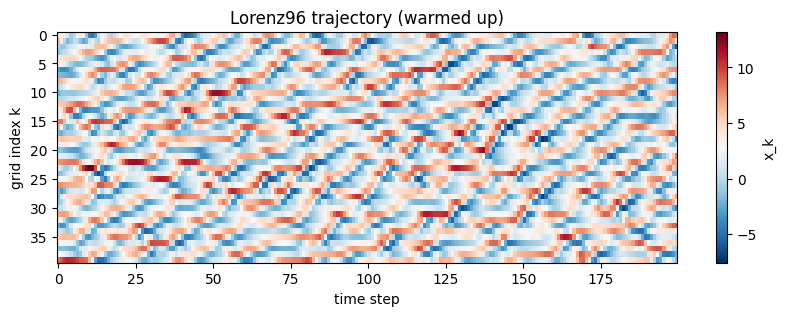

In [5]:
# Quick sanity plot: integrate a random initial state, show a Hovmoller diagram.
x0 = torch.randn(40, device=device) * 0.5
x0 = L96.warmup(x0, total_inner_steps=2000)  # spin up to attractor
traj = L96.integrate(x0, n_steps=200)  # (200, 40)

plt.figure(figsize=(10, 3))
plt.imshow(traj.cpu().numpy().T, aspect='auto', cmap='RdBu_r')
plt.colorbar(label='x_k')
plt.xlabel('time step'); plt.ylabel('grid index k')
plt.title('Lorenz96 trajectory (warmed up)')
plt.show()

### Data generation and spatial correlation

`generate_data` returns `(X0, X_true, Y)` where `Y = H(X_true) + noise`. Also computes a long trajectory for estimating the spatial correlation matrix `C` used to precondition the optimizer.

In [6]:
def generate_data(dyn_sys, n_samples, n_time_steps, n_warmup, obs_noise_std=0.0, seed=0):
    g = torch.Generator(device=device).manual_seed(seed)
    X0_cold = torch.randn(n_samples, dyn_sys.grid_size, device=device, generator=g) * 0.5
    # Spin up each trajectory independently.
    X0 = torch.stack([dyn_sys.warmup(x, n_warmup) for x in X0_cold], dim=0)
    # Forward integration.
    X = torch.stack([dyn_sys.integrate(x, n_time_steps) for x in X0], dim=0)  # (N, T, grid)
    Y_clean = dyn_sys.observe(X)                                               # (N, T, obs_grid)
    noise = torch.empty_like(Y_clean).normal_(generator=g) * obs_noise_std
    Y = Y_clean + noise
    return X0, X, Y, Y_clean

def generate_data_fast(dyn_sys, n_samples, n_time_steps, n_warmup,
                        obs_noise_std=0.0, seed=0):
      """Fully batched — processes all N samples in parallel."""
      g = torch.Generator(device=device).manual_seed(seed)

      # All samples at once: (N, grid)
      X0_cold = torch.randn(n_samples, dyn_sys.grid_size, device=device, generator=g) * 0.5

      # Batched warmup
      x = X0_cold
      for _ in range(n_warmup):
          x = rk4_step(dyn_sys.rhs, x, dyn_sys.dt)  # (N, grid) all at once
      X0 = x

      # Batched integrate
      traj = [X0]
      x = X0
      for _ in range(n_time_steps - 1):
          for _ in range(dyn_sys.n_inner):
              x = rk4_step(dyn_sys.rhs, x, dyn_sys.dt)
          traj.append(x)
      X = torch.stack(traj, dim=1)  # (N, T, grid)

      Y_clean = dyn_sys.observe(X)
      noise = torch.randn_like(Y_clean, generator=g) * obs_noise_std

      return X0, X, Y_clean + noise, None


def estimate_correlation(dyn_sys, n_samples=2000, n_warmup=1000, seed=1):
    # One long ensemble of warmed-up states. C is estimated over the ensemble.
    g = torch.Generator(device=device).manual_seed(seed)
    X0 = torch.randn(n_samples, dyn_sys.grid_size, device=device, generator=g) * 0.5
    X = torch.stack([dyn_sys.warmup(x, n_warmup) for x in X0], dim=0)  # (N, grid)
    X = X - X.mean(dim=0, keepdim=True)
    C = (X.T @ X) / (X.shape[0] - 1)  # (grid, grid)
    # Symmetric matrix square root via eigendecomposition.
    eigvals, eigvecs = torch.linalg.eigh(C)
    eigvals = torch.clamp(eigvals, min=1e-8)
    C_sqrt = eigvecs @ torch.diag(eigvals.sqrt()) @ eigvecs.T
    C_inv_sqrt = eigvecs @ torch.diag(eigvals.rsqrt()) @ eigvecs.T
    C_inv = eigvecs @ torch.diag(1.0 / eigvals) @ eigvecs.T
    return dict(C=C, C_sqrt=C_sqrt, C_inv_sqrt=C_inv_sqrt, C_inv=C_inv)


corr = load_cache('l96_corr.pt')
if corr is None:
    corr = estimate_correlation(L96, n_samples=1000, n_warmup=500)
    save_cache(corr, 'l96_corr.pt')
print('C shape:', corr['C'].shape, 'cond=', torch.linalg.cond(corr['C']).item())

  [cache] loaded l96_corr.pt
C shape: torch.Size([40, 40]) cond= 8.721698760986328


### Inverse observation operator $H^{-1}_\theta$

Maps an *observation sequence* $Y \in \mathbb{R}^{T \times n_{obs}}$ back to full physical space $X \in \mathbb{R}^{T \times n_{grid}}$. CNN with **periodic** padding in the grid dimension and **zero** padding in time (matches the paper's `PeriodicSpaceConv`).

In [7]:
class PeriodicSpaceConv2d(nn.Module):
    """Conv2d over (time, space). Space gets periodic padding, time gets zero padding."""
    def __init__(self, in_ch, out_ch, k_t=3, k_x=3):
        super().__init__()
        self.k_t = k_t
        self.k_x = k_x
        # Inner conv has 'valid' behavior; we pad manually.
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=(k_t, k_x), padding=0)

    def forward(self, x):  # x: (B, C, T, X)
        pt = (self.k_t - 1) // 2
        px = (self.k_x - 1) // 2
        x = F.pad(x, (px, px, 0, 0), mode='circular')  # wrap space
        x = F.pad(x, (0, 0, pt, pt), mode='constant')  # zero time
        return self.conv(x)


class InverseObsLorenz96(nn.Module):
    def __init__(self, obs_grid=10, full_grid=40, hidden=32, n_layers=6):
        super().__init__()
        self.obs_grid = obs_grid
        self.full_grid = full_grid
        self.in_proj = PeriodicSpaceConv2d(1, hidden, 3, 3)
        self.blocks = nn.ModuleList(
            [PeriodicSpaceConv2d(hidden, hidden, 3, 3) for _ in range(n_layers)]
        )
        self.out_proj = PeriodicSpaceConv2d(hidden, 1, 3, 3)

    def forward(self, y):  # y: (B, T, obs_grid) -> (B, T, full_grid)
        B, T, _ = y.shape
        x = y.unsqueeze(1)  # (B, 1, T, obs_grid)
        # Spatial upsample with periodic-aware linear interp:
        x = F.interpolate(x, size=(T, self.full_grid), mode='bilinear', align_corners=False)
        x = F.gelu(self.in_proj(x))
        for blk in self.blocks:
            x = x + F.gelu(blk(x))
        x = self.out_proj(x)
        return x.squeeze(1)

### Train the inverse observation operator

Supervised regression: integrate trajectories, observe them, teach the net to invert $H$.

  [cache] loaded l96_inverter_sigma0.0.pt


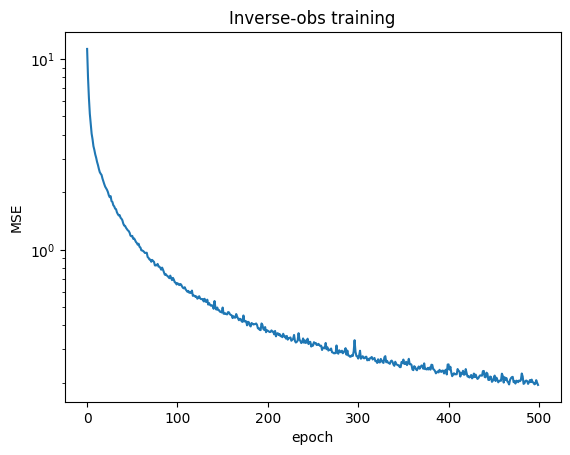

In [8]:
def train_inverter(dyn_sys, inverter, n_train=40000, T_train=20, n_warmup=1000,
                   n_epochs=500, batch_size=8, lr=1e-3, obs_noise_std=0.0, log_every=5):
    # Build a dataset once.
    _, X, Y, _ = generate_data_fast(dyn_sys, n_train, T_train, n_warmup,
                                obs_noise_std=obs_noise_std, seed=42)
    X = X.detach(); Y = Y.detach()
    opt = torch.optim.Adam(inverter.parameters(), lr=lr)
    n = X.shape[0]
    history = []
    for epoch in range(n_epochs):
        perm = torch.randperm(n, device=device)
        ep_loss = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            y_b, x_b = Y[idx], X[idx]
            pred = inverter(y_b)
            loss = F.mse_loss(pred, x_b)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item() * idx.numel()
        ep_loss /= n
        history.append(ep_loss)
        if epoch % log_every == 0 or epoch == n_epochs - 1:
            print(f'  epoch {epoch:3d}  loss={ep_loss:.4f}')
    return history


inverter = InverseObsLorenz96(obs_grid=10, full_grid=40, hidden=32, n_layers=6).to(device)
ckpt = load_cache('l96_inverter_sigma0.0.pt')
if ckpt is None:
    hist = train_inverter(L96, inverter, n_train=400, T_train=20, n_epochs=500,
                          batch_size=8, obs_noise_std=0.0)
    save_cache({'state_dict': inverter.state_dict(), 'hist': hist}, 'l96_inverter_sigma0.0.pt')
else:
    inverter.load_state_dict(ckpt['state_dict'])
    hist = ckpt['hist']

plt.plot(hist); plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('MSE')
plt.title('Inverse-obs training'); plt.show()

### Variational DA

Three optimization modes from the paper:
- **obs-space**: minimize $\|H(M(x_0)) - y\|^2$
- **physics-space**: minimize $\|M(x_0) - H^{-1}_\theta(y)\|^2$
- **hybrid**: physics-space warm-start → obs-space refinement

All operate in decorrelated coordinates $z = C^{-1/2} x$ (classic 4D-Var preconditioning).

In [9]:
def decorrelate(x, C_inv_sqrt):
    # x: (..., grid) -> z: (..., grid)
    return x @ C_inv_sqrt  # C is symmetric so left/right multiply is equivalent


def correlate(z, C_sqrt):
    return z @ C_sqrt


def da_loss(Z0, Y, dyn_sys, C_sqrt, T, mode, inverter=None):
    """Batched DA loss.
    Z0: (N, grid) decorrelated initial states.
    Y:  (N, T, obs_grid) observations.
    Returns scalar (mean over N samples, T steps, and obs components).
    """
    X0 = correlate(Z0, C_sqrt)           # (N, grid)
    traj = dyn_sys.integrate(X0, T)      # (T, N, grid) — rhs broadcasts over leading dims
    if mode == 'obs':
        pred = dyn_sys.observe(traj)     # (T, N, obs_grid)
        target = Y.transpose(0, 1)       # (T, N, obs_grid)
    elif mode == 'physics':
        assert inverter is not None
        inv = inverter(Y).detach()       # (N, T, grid)
        target = inv.transpose(0, 1)     # (T, N, grid)
        pred = traj
    else:
        raise ValueError(mode)
    return ((pred - target) ** 2).mean()


def lbfgs_minimize(loss_fn, z0_init, max_iter=200, history_size=20, lr=1.0):
    z = z0_init.clone().detach().requires_grad_(True)
    opt = torch.optim.LBFGS([z], max_iter=max_iter, history_size=history_size,
                            tolerance_grad=1e-12, tolerance_change=1e-12,
                            line_search_fn='strong_wolfe', lr=lr)
    history = []

    def closure():
        opt.zero_grad()
        loss = loss_fn(z)
        loss.backward()
        history.append(loss.item())
        return loss

    opt.step(closure)
    return z.detach(), history

In [10]:
def run_da(dyn_sys, inverter, corr, X0_init, Y, T,
           physics_steps=0, obs_steps=500):
    """Batched DA: all N samples optimized in a single L-BFGS call.
    X0_init: (N, grid), Y: (N, T, obs_grid). Returns X0_opt: (N, grid) and loss history."""
    C_sqrt, C_inv_sqrt = corr['C_sqrt'], corr['C_inv_sqrt']
    Z0 = decorrelate(X0_init, C_inv_sqrt)
    hist = []
    if physics_steps > 0:
        loss_p = partial(da_loss, Y=Y, dyn_sys=dyn_sys, C_sqrt=C_sqrt, T=T,
                         mode='physics', inverter=inverter)
        Z0, h1 = lbfgs_minimize(loss_p, Z0, max_iter=physics_steps)
        hist.extend(h1)
    if obs_steps > 0:
        loss_o = partial(da_loss, Y=Y, dyn_sys=dyn_sys, C_sqrt=C_sqrt, T=T,
                         mode='obs')
        Z0, h2 = lbfgs_minimize(loss_o, Z0, max_iter=obs_steps)
        hist.extend(h2)
    X0_opt = correlate(Z0, C_sqrt)
    return X0_opt, hist


def baseline_init_l96(dyn_sys, Y):
    """Batched baseline init: nearest-neighbor upsample from t=0 observations.
    Y: (N, T, obs_grid) or (T, obs_grid). Returns (N, grid) or (grid,)."""
    if Y.ndim == 3:
        return Y[:, 0].repeat_interleave(dyn_sys.observe_every, dim=-1)
    return Y[0].repeat_interleave(dyn_sys.observe_every)

In [11]:
# 4D-Var cost functions in decorrelated z-coordinates.
# Both operate on batched z0 of shape (N, grid); each row is independently optimized
# (its gradient depends only on its own observations), so L-BFGS over the flat (N*grid)
# vector is equivalent to N independent 4D-Var problems.

def var4d_cost_obs(z0, y_T, dyn_sys, C_sqrt, T, z_b, R_inv_diag, sigma_b):
    """Standard 4D-Var: J_b + J_o.

    z0, z_b: (N, grid).  y_T: (T, N, obs_grid) (already transposed).
    With B = sigma_b^2 * C, decorrelating gives J_b = ||z0 - z_b||^2 / (2 sigma_b^2).
    """
    x0 = correlate(z0, C_sqrt)
    traj = dyn_sys.integrate(x0, T)            # (T, N, grid)
    y_pred = dyn_sys.observe(traj)             # (T, N, obs_grid)
    innov = y_pred - y_T
    J_o = 0.5 * (innov.pow(2) * R_inv_diag).sum()
    J_b = 0.5 * ((z0 - z_b).pow(2)).sum() / (sigma_b ** 2)
    return J_b + J_o


def var4d_cost_phys(z0, target_traj, dyn_sys, C_sqrt, T, z_b, sigma_b, sigma_p):
    """Physics-space companion cost: J_b + (1/2 sigma_p^2) ||M(x_0) - H^{-1}_theta(y)||^2.

    target_traj: precomputed (T, N, grid) = inverter(Y).detach().transpose(0,1).
    """
    x0 = correlate(z0, C_sqrt)
    traj = dyn_sys.integrate(x0, T)            # (T, N, grid)
    J_phys = 0.5 * ((traj - target_traj).pow(2)).sum() / (sigma_p ** 2)
    J_b = 0.5 * ((z0 - z_b).pow(2)).sum() / (sigma_b ** 2)
    return J_b + J_phys


In [12]:
def invobs_init_l96(inverter, Y):
    """Background estimate from H^{-1}_theta evaluated at the observation sequence.
    Y: (N, T, obs_grid) -> (N, grid). Uses the first frame of the inverted trajectory."""
    return inverter(Y).detach()[:, 0]


def run_4dvar_l96(dyn_sys, inverter, corr, X0_init, Y, T,
                  sigma_b=1.0, sigma_obs=0.5, sigma_p=0.5,
                  mode='obs', physics_steps=200, obs_steps=300):
    """Full 4D-Var driver. X0_init also acts as the background x_b.

    mode = 'obs'    : minimize J_b + J_o for `obs_steps` L-BFGS iterations (classical 4D-Var).
    mode = 'hybrid' : first minimize J_b + J_phys for `physics_steps` iters, then J_b + J_o.

    Returns (X0_opt: (N, grid), loss_history: list).
    """
    C_sqrt, C_inv_sqrt = corr['C_sqrt'], corr['C_inv_sqrt']
    z_b = decorrelate(X0_init, C_inv_sqrt)
    R_inv_diag = torch.full((dyn_sys.grid_size // dyn_sys.observe_every,),
                            1.0 / (sigma_obs ** 2), device=device)
    Y_T = Y.transpose(0, 1)                                 # (T, N, obs_grid)
    z = z_b.clone()
    history = []

    if mode == 'hybrid':
        target_traj = inverter(Y).detach().transpose(0, 1)  # (T, N, grid)
        loss_phys = partial(var4d_cost_phys, target_traj=target_traj,
                            dyn_sys=dyn_sys, C_sqrt=C_sqrt, T=T,
                            z_b=z_b, sigma_b=sigma_b, sigma_p=sigma_p)
        z, h_p = lbfgs_minimize(loss_phys, z, max_iter=physics_steps)
        history.extend(h_p)

    loss_obs = partial(var4d_cost_obs, y_T=Y_T, dyn_sys=dyn_sys, C_sqrt=C_sqrt, T=T,
                       z_b=z_b, R_inv_diag=R_inv_diag, sigma_b=sigma_b)
    z, h_o = lbfgs_minimize(loss_obs, z, max_iter=obs_steps)
    history.extend(h_o)

    X0_opt = correlate(z, C_sqrt)
    return X0_opt, history


In [13]:
NOISE_LEVELS = [0.1, 0.5, 1.0]  # σ_obs

inverters_by_noise = {}

for sigma in NOISE_LEVELS:
    print(f'\n=== σ_obs = {sigma} ===')
    inv_sigma = InverseObsLorenz96(obs_grid=10, full_grid=40, hidden=32, n_layers=6).to(device)
    ckpt_name = f'l96_inverter_sigma{sigma}.pt'
    ckpt = load_cache(ckpt_name)
    if ckpt is None:
        _ = train_inverter(L96, inv_sigma,
                           n_train=32000, T_train=10,   # paper scale
                           n_epochs=500, batch_size=8,
                           obs_noise_std=sigma, log_every=50)
        save_cache({'state_dict': inv_sigma.state_dict()}, ckpt_name)
    else:
        inv_sigma.load_state_dict(ckpt['state_dict'])
    inverters_by_noise[sigma] = inv_sigma


=== σ_obs = 0.1 ===
  [cache] loaded l96_inverter_sigma0.1.pt

=== σ_obs = 0.5 ===
  [cache] loaded l96_inverter_sigma0.5.pt

=== σ_obs = 1.0 ===
  [cache] loaded l96_inverter_sigma1.0.pt


In [14]:
# --- Experiment A: 4-combo trajectory L1 error (mirrors paper Fig 4) ---
N_EVAL    = 100   # paper uses 100 test trajectories
T_EVAL    = 10    # paper uses T=10 assimilation window
T_FORECAST_A = 20
T_TOTAL_A    = T_EVAL + T_FORECAST_A

combos_expA = {
    'baseline + obs':    {'init': 'baseline', 'p_steps': 0,   'o_steps': 500},
    'invobs + obs':      {'init': 'invobs',   'p_steps': 0,   'o_steps': 500},
    'baseline + hybrid': {'init': 'baseline', 'p_steps': 100, 'o_steps': 400},
    'invobs + hybrid':   {'init': 'invobs',   'p_steps': 100, 'o_steps': 400},
}

cb_colors_A     = ['#d62728', '#2171b5', '#d62728', '#2171b5']
cb_linestyles_A = ['--',      '--',      '-',        '-'     ]
cb_markers_A    = ['s',       'o',       's',        'o'     ]

cache_key_A = f'l96_expA_4combo_N{N_EVAL}_T{T_EVAL}.pt'
cached_A    = load_cache(cache_key_A)

if cached_A is None:
    expA_xrec  = {}
    expA_truth = {}
    for sigma in NOISE_LEVELS:
        # Use already-trained inverter from Cell 19 — no retraining needed
        inv_sigma = inverters_by_noise[sigma]

        print(f'\n=== Running DA combos for σ={sigma} ===')
        X0_gt, _, Y, _ = generate_data(L96, n_samples=N_EVAL, n_time_steps=T_EVAL,
                                        n_warmup=500, obs_noise_std=sigma, seed=100)
        expA_truth[sigma] = X0_gt.detach()
        expA_xrec[sigma]  = {}

        inits = {
            'baseline': baseline_init_l96(L96, Y),
            'invobs':   inv_sigma(Y).detach()[:, 0],
        }
        for name, cfg in combos_expA.items():
            X0_opt, _ = run_da(L96, inv_sigma, corr, inits[cfg['init']], Y, T=T_EVAL,
                               physics_steps=cfg['p_steps'], obs_steps=cfg['o_steps'])
            expA_xrec[sigma][name] = X0_opt.detach()
            rmse = ((X0_opt - X0_gt) ** 2).mean(dim=-1).sqrt().mean().item()
            print(f'  sigma={sigma}  {name:22s}  x0 RMSE={rmse:.4f}')

    save_cache({'xrec': expA_xrec, 'truth': expA_truth}, cache_key_A)
else:
    expA_xrec  = cached_A['xrec']
    expA_truth = cached_A['truth']
    # Key normalisation in case cache was written with old key names
    _key_map = {
        'obs  + baseline init': 'baseline + obs',
        'obs  + invobs init':   'invobs + obs',
        'hybrid + baseline init': 'baseline + hybrid',
        'hybrid + invobs init':   'invobs + hybrid',
    }
    for sigma in NOISE_LEVELS:
        expA_xrec[sigma] = {_key_map.get(k, k): v for k, v in expA_xrec[sigma].items()}
    print('Loaded Experiment A from cache.')
    print('Keys:', list(expA_xrec[NOISE_LEVELS[0]].keys()))

  [cache] loaded l96_expA_4combo_N100_T10.pt
Loaded Experiment A from cache.
Keys: ['baseline + obs', 'invobs + obs', 'baseline + hybrid', 'invobs + hybrid']


γ = 4.1437


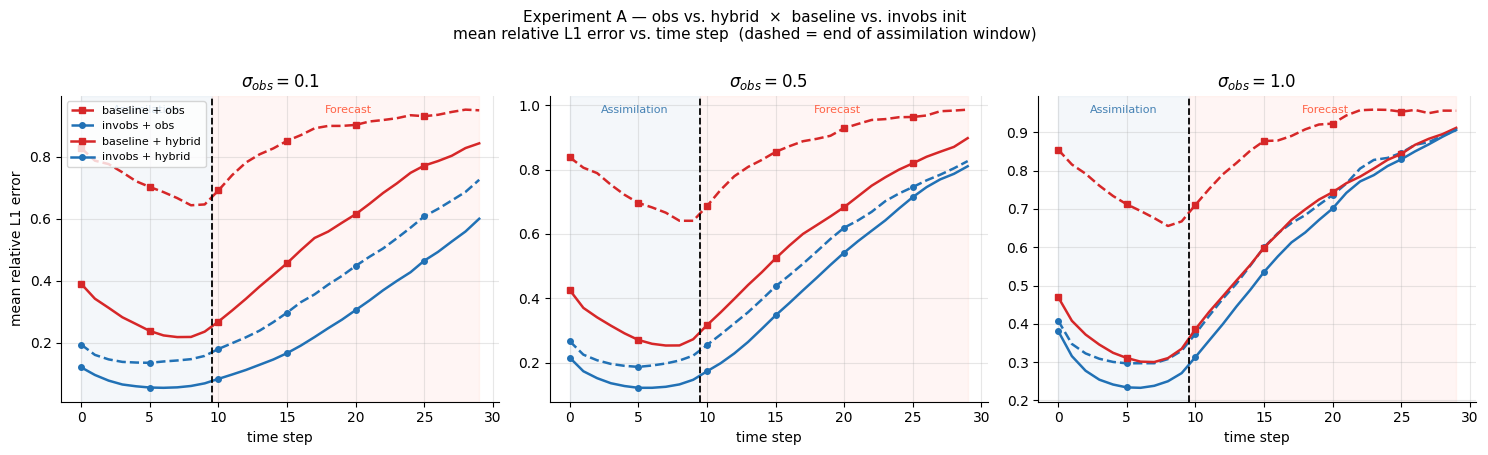

In [15]:
# --- Experiment A: Fig 4-style plot, one panel per noise level ---

# Compute γ: mean L1 between random independent states (paper eq. 5)
_, X_ref, _, _ = generate_data(L96, n_samples=1000, n_time_steps=2,
                                n_warmup=500, obs_noise_std=0.0, seed=999)
x1, x2 = X_ref[:500, 0, :], X_ref[500:, 0, :]
gamma = (x1 - x2).abs().mean().item()
print(f'γ = {gamma:.4f}')

fig, axes = plt.subplots(1, len(NOISE_LEVELS), figsize=(15, 4.5), sharey=False)

for col, sigma in enumerate(NOISE_LEVELS):
    ax = axes[col]
    X0_gt   = expA_truth[sigma]
    X_truth = L96.integrate(X0_gt, T_TOTAL_A)   # (T_TOTAL_A, N, grid)

    for i, name in enumerate(combos_expA):
        X_pred = L96.integrate(expA_xrec[sigma][name], T_TOTAL_A)
        l1_t = (X_pred - X_truth).abs().mean(dim=-1).mean(dim=-1).detach().cpu().numpy()
        l1_t = l1_t / gamma   # scale to relative error (paper eq. 5)
        ax.plot(l1_t, label=name,
                color=cb_colors_A[i], linestyle=cb_linestyles_A[i],
                marker=cb_markers_A[i], markersize=4, markevery=5, lw=1.8)

    sep = T_EVAL - 0.5
    ax.axvline(sep, color='k', lw=1.3, ls='--')
    ax.axvspan(0,   sep,            alpha=0.06, color='steelblue')
    ax.axvspan(sep, T_TOTAL_A - 1,  alpha=0.06, color='tomato')
    ax.text(sep * 0.5,              0.97, 'Assimilation',
            transform=ax.get_xaxis_transform(), fontsize=8,
            ha='center', color='steelblue', va='top')
    ax.text(sep + T_FORECAST_A*0.5, 0.97, 'Forecast',
            transform=ax.get_xaxis_transform(), fontsize=8,
            ha='center', color='tomato', va='top')

    ax.set_title(f'$\\sigma_{{obs}} = {sigma}$')
    ax.set_xlabel('time step')
    ax.grid(alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('mean relative L1 error')
axes[0].legend(fontsize=8, loc='upper left')

plt.suptitle(
    'Experiment A — obs vs. hybrid  ×  baseline vs. invobs init\n'
    'mean relative L1 error vs. time step  (dashed = end of assimilation window)',
    y=1.00, fontsize=11
)
plt.subplots_adjust(top=0.82)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/l96_expA_trajectory_l1.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sliding-window (cycling) 4D-Var

Given an optimized analysis state $x_a^{(k)}$ from assimilation window $k$, the dynamical model is integrated forward to produce the next background state:

$$
x_b^{(k+1)} = M^{(\Delta t)}\left(x_a^{(k)}\right),
$$

where $M^{(\Delta t)}$ denotes evolution of the Lorenz96 dynamics over the stride between consecutive windows.

At each cycle:

1. A new observation window
$$
(y_t,\dots,y_{t+T})
$$
is extracted from the full trajectory.

2. The previous analysis forecast is used as the background state $x_b$.

3. We solve the hybrid 4D-Var optimization problem:
   - first minimizing the auxiliary physics-space objective
$$
\tilde J(x_0)
=
\sum_{t=0}^{T}
\|x_t - h_\theta(y_t)\|_2^2,
$$

   - followed by refinement with the standard observation-space 4D-Var objective.

4. The optimized analysis is forecast forward and recycled into the next assimilation window.

This cycling procedure allows the background estimate to improve over repeated assimilation windows. In chaotic systems such as Lorenz96, early cycles may contain relatively large errors because the initial background is weak. However, after several assimilation windows, the propagated analyses become increasingly informative, reducing analysis RMSE and stabilizing the trajectory estimate.

To improve stability during cycling, we used a smaller background variance parameter $\sigma_b$, corresponding to stronger trust in the propagated background state from the previous window. In decorrelated coordinates, the background penalty becomes

$$
\frac{1}{2\sigma_b^2}\|z-z_b\|^2,
$$

so decreasing $\sigma_b$ increases the weight placed on the prior forecast trajectory.

In [16]:
def run_sliding_window_4dvar_l96(
    dyn_sys, inverter, corr, Y_long,
    window_T=10,
    stride=1,
    sigma_b=1.0,
    sigma_obs=0.5,
    sigma_p=0.5,
    init_mode='invobs',
    opt_mode='hybrid',
    physics_steps=100,
    obs_steps=200,
):
    """
    Sliding-window / cycling 4D-Var.

    Y_long: (N, T_total, obs_grid)
    For each cycle:
      1. take observation window Y[:, start:start+window_T]
      2. optimize x_start
      3. forecast optimized x_start forward by `stride`
      4. use that forecast as background for next cycle
    """
    N, T_total, _ = Y_long.shape
    starts = list(range(0, T_total - window_T + 1, stride))

    analyses = []
    backgrounds = []
    histories = []

    xb = None

    for c, start in enumerate(starts):
        Y_win = Y_long[:, start:start + window_T]

        if c == 0:
            if init_mode == 'baseline':
                xb = baseline_init_l96(dyn_sys, Y_win)
            elif init_mode == 'invobs':
                xb = invobs_init_l96(inverter, Y_win)
            else:
                raise ValueError(init_mode)

        X0_opt, hist = run_4dvar_l96(
            dyn_sys=dyn_sys,
            inverter=inverter,
            corr=corr,
            X0_init=xb,
            Y=Y_win,
            T=window_T,
            sigma_b=sigma_b,
            sigma_obs=sigma_obs,
            sigma_p=sigma_p,
            mode=opt_mode,
            physics_steps=physics_steps,
            obs_steps=obs_steps,
        )

        analyses.append(X0_opt.detach())
        backgrounds.append(xb.detach())
        histories.append(hist)

        # Forecast analysis forward to become next window background
        if start != starts[-1]:
            xb = dyn_sys.integrate(X0_opt.detach(), stride + 1)[-1].detach()

    return {
        'starts': starts,
        'analyses': torch.stack(analyses, dim=1),      # (N, n_cycles, grid)
        'backgrounds': torch.stack(backgrounds, dim=1), # (N, n_cycles, grid)
        'histories': histories,
    }

### Run sliding-window cycling 4D-Var experiment

We evaluate the cycling assimilation framework on long Lorenz 96 trajectories divided into overlapping assimilation windows. For each cycle, the analysis state from the previous window is propagated forward and used as the background state for the next cycle.

The experiment uses the inverter trained at the corresponding observation noise level so that the learned inverse observation operator $H^{-1}_\theta$ remains matched to the test distribution throughout the cycling process.

For each assimilation cycle we record:
- the background RMSE before assimilation,
- the analysis RMSE after 4D-Var optimization,
- and the evolution of errors across repeated windows.

This allows us to test whether the learned initialization improves not only single-window reconstruction accuracy, but also long-term stability and forecast quality over repeated assimilation cycles.

In [25]:
# Run sliding-window experiment
N_EVAL_SW = 50
T_TOTAL_SW = 30
WINDOW_T_SW = 10
STRIDE_SW = 1
SIGMA_OBS_SW = 0.1
SIGMA_B_SW = 0.3

inv_sw = inverters_by_noise[SIGMA_OBS_SW]

X0_gt_sw, X_true_sw, Y_sw, _ = generate_data(
    L96,
    n_samples=N_EVAL_SW,
    n_time_steps=T_TOTAL_SW,
    n_warmup=500,
    obs_noise_std=SIGMA_OBS_SW,
    seed=777,
)

sw_result = run_sliding_window_4dvar_l96(
    dyn_sys=L96,
    inverter=inv_sw,
    corr=corr,
    Y_long=Y_sw,
    window_T=WINDOW_T_SW,
    stride=STRIDE_SW,
    sigma_b=SIGMA_B_SW,
    sigma_obs=SIGMA_OBS_SW,
    sigma_p=SIGMA_OBS_SW,
    init_mode='invobs',
    opt_mode='hybrid',
    physics_steps=100,
    obs_steps=200,
)

print("Sliding-window cycles:", len(sw_result['starts']))
print("Window starts:", sw_result['starts'])
print("Analyses shape:", sw_result['analyses'].shape)

Sliding-window cycles: 21
Window starts: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Analyses shape: torch.Size([50, 21, 40])


/tmp/ipykernel_2148/2441807154.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


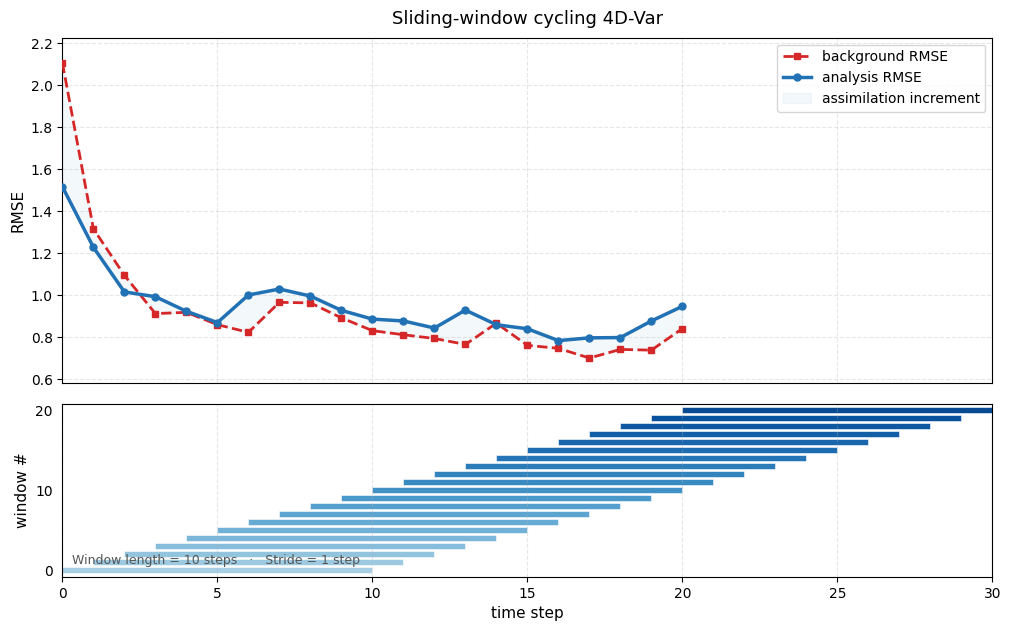

In [18]:
# --- Plot sliding-window cycling 4D-Var: two-panel (RMSE + Gantt) ---

starts    = sw_result['starts']
analyses  = sw_result['analyses']    # (N, cycles, grid)
backgrounds = sw_result['backgrounds']  # (N, cycles, grid)

cycle_rmse_analysis = []
cycle_rmse_background = []

for j, start in enumerate(starts):
    truth_at_start = X_true_sw[:, start, :]     # (N, grid)

    analysis_j   = analyses[:, j, :]            # (N, grid)
    background_j = backgrounds[:, j, :]         # (N, grid)

    rmse_a = ((analysis_j   - truth_at_start) ** 2).mean(dim=-1).sqrt()
    rmse_b = ((background_j - truth_at_start) ** 2).mean(dim=-1).sqrt()

    cycle_rmse_analysis.append(rmse_a.detach().cpu().numpy())
    cycle_rmse_background.append(rmse_b.detach().cpu().numpy())

mean_rmse_analysis   = np.stack(cycle_rmse_analysis,   axis=1).mean(axis=0)
mean_rmse_background = np.stack(cycle_rmse_background, axis=1).mean(axis=0)

fig, (ax_rmse, ax_gantt) = plt.subplots(
    2, 1, figsize=(12, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08}
)

# --- Top panel: background vs analysis RMSE ---
ax_rmse.plot(
    starts, mean_rmse_background,
    marker='s', linewidth=2.0, markersize=5,
    color='#d62728', linestyle='--', label='background RMSE', zorder=4
)
ax_rmse.plot(
    starts, mean_rmse_analysis,
    marker='o', linewidth=2.5, markersize=5,
    color='#2171b5', label='analysis RMSE', zorder=5
)

# Shaded region between the two curves highlights assimilation increment
ax_rmse.fill_between(
    starts, mean_rmse_background, mean_rmse_analysis,
    alpha=0.12, color='#9ecae1',
    label='assimilation increment'
)

y_min = min(mean_rmse_analysis.min(), mean_rmse_background.min()) - 0.12
y_max = max(mean_rmse_analysis.max(), mean_rmse_background.max()) + 0.12
ax_rmse.set_ylim(y_min, y_max)
ax_rmse.set_ylabel('RMSE', fontsize=11)
ax_rmse.grid(True, alpha=0.3, linestyle='--')
ax_rmse.legend(loc='upper right', fontsize=10)
ax_rmse.set_title('Sliding-window cycling 4D-Var', fontsize=13, pad=10)
ax_rmse.tick_params(bottom=False)

# --- Bottom panel: Gantt-style window timeline ---
n_windows = len(starts)
cmap   = plt.get_cmap('Blues')
colors = [cmap(0.35 + 0.55 * i / (n_windows - 1)) for i in range(n_windows)]

for i, s in enumerate(starts):
    ax_gantt.barh(
        y=i, width=WINDOW_T_SW, left=s,
        height=0.75, color=colors[i],
        edgecolor='white', linewidth=0.4
    )

ax_gantt.set_xlabel('time step', fontsize=11)
ax_gantt.set_ylabel('window #', fontsize=11)
ax_gantt.set_xlim(0, T_TOTAL_SW)
ax_gantt.set_ylim(-0.8, n_windows - 0.2)
ax_gantt.set_yticks([0, n_windows // 2, n_windows - 1])
ax_gantt.grid(axis='x', alpha=0.3, linestyle='--')
ax_gantt.tick_params(left=False)

ax_gantt.text(
    0.01, 0.06,
    f'Window length = {WINDOW_T_SW} steps   ·   Stride = {STRIDE_SW} step',
    transform=ax_gantt.transAxes,
    fontsize=9, color='#555',
    verticalalignment='bottom'
)

plt.tight_layout()
plt.show()

In [19]:
# --- Single-window experiment on last window only ---
last_start = sw_result['starts'][-1]  # = 20

Y_last = Y_sw[:, last_start:last_start + WINDOW_T_SW]  # (N, 10, obs_grid)

# Cold-start background — same init_mode as cycling for fair comparison
xb_cold = invobs_init_l96(inv_sw, Y_last)

X0_single, hist_single = run_4dvar_l96(
    dyn_sys=L96,
    inverter=inv_sw,
    corr=corr,
    X0_init=xb_cold,
    Y=Y_last,
    T=WINDOW_T_SW,
    sigma_b=SIGMA_B_SW,
    sigma_obs=SIGMA_OBS_SW,
    sigma_p=SIGMA_OBS_SW,
    mode='hybrid',
    physics_steps=100,
    obs_steps=200,
)

# --- Compare RMSE at step 20 ---
truth_last = X_true_sw[:, last_start, :]  # (N, grid)

# Cycling analysis RMSE at last cycle
analysis_cycling = sw_result['analyses'][:, -1, :]
rmse_cycling = ((analysis_cycling - truth_last) ** 2).mean(dim=-1).sqrt().mean().item()

# Single-window analysis RMSE
rmse_single = ((X0_single - truth_last) ** 2).mean(dim=-1).sqrt().mean().item()

# Cold-start background RMSE
rmse_background = ((xb_cold - truth_last) ** 2).mean(dim=-1).sqrt().mean().item()

print(f"Background RMSE (cold start): {rmse_background:.4f}")
print(f"Single-window analysis RMSE: {rmse_single:.4f}")
print(f"Cycling analysis RMSE: {rmse_cycling:.4f}")

Background RMSE (cold start): 2.1631
Single-window analysis RMSE: 1.6416
Cycling analysis RMSE: 0.9463


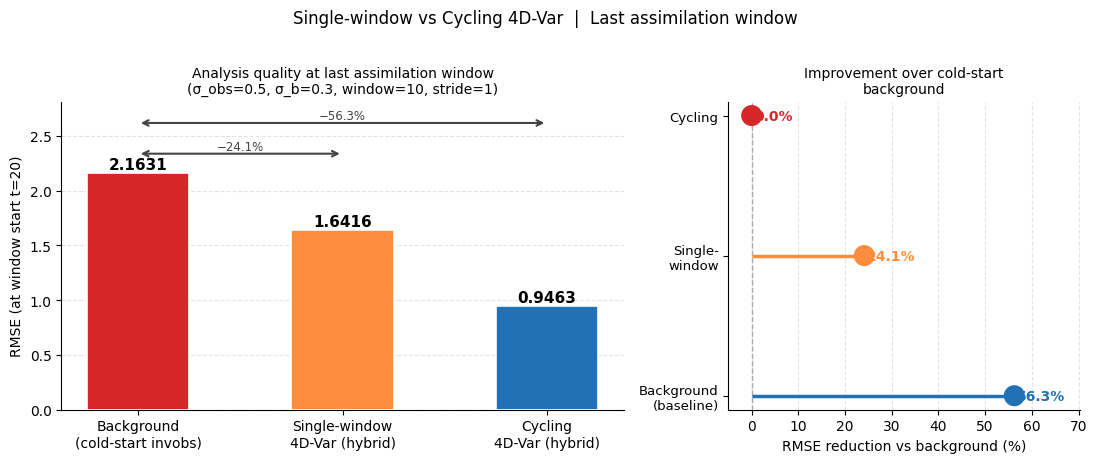

In [20]:
# --- Visualise the three RMSE values at the last window ---
import matplotlib.patches as mpatches

labels  = ['Background\n(cold-start invobs)', 'Single-window\n4D-Var (hybrid)', 'Cycling\n4D-Var (hybrid)']
values  = [rmse_background, rmse_single, rmse_cycling]
colors  = ['#d62728', '#fd8d3c', '#2171b5']   # red → orange → blue (worse → better)
hatches = ['///', '', '']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5),
                         gridspec_kw={'width_ratios': [1.6, 1]})

# ── Left: annotated bar chart ────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(labels, values, color=colors, width=0.5,
              edgecolor='white', linewidth=1.2, zorder=3)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.005,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Improvement arrows
def draw_arrow(ax, x0, x1, y, label):
    ax.annotate('', xy=(x1, y), xytext=(x0, y),
                arrowprops=dict(arrowstyle='<->', color='#444', lw=1.5))
    ax.text((x0 + x1) / 2, y + 0.008, label,
            ha='center', va='bottom', fontsize=8.5, color='#444')

y_arrow = max(values) * 1.08
draw_arrow(ax, 0, 1, y_arrow,
           f'−{100*(rmse_background-rmse_single)/rmse_background:.1f}%')
draw_arrow(ax, 0, 2, y_arrow * 1.12,
           f'−{100*(rmse_background-rmse_cycling)/rmse_background:.1f}%')

ax.set_ylim(0, max(values) * 1.30)
ax.set_ylabel('RMSE (at window start t=20)', fontsize=10)
ax.set_title(f'Analysis quality at last assimilation window\n'
             f'(σ_obs={SIGMA_OBS_SW}, σ_b={SIGMA_B_SW}, '
             f'window={WINDOW_T_SW}, stride={STRIDE_SW})', fontsize=10)
ax.grid(axis='y', alpha=0.35, linestyle='--', zorder=0)
ax.tick_params(axis='x', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)

# ── Right: reduction-from-background dot plot ─────────────────────────────────
ax2 = axes[1]
methods_short = ['Background\n(baseline)', 'Single-\nwindow', 'Cycling']
reductions = [0.0,
              (rmse_background - rmse_single)  / rmse_background * 100,
              (rmse_background - rmse_cycling) / rmse_background * 100]

ax2.scatter(reductions, [2, 1, 0], c=colors, s=200, zorder=4)
ax2.hlines([2, 1, 0], 0, reductions, colors=colors, linewidths=2.5, zorder=3)
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(methods_short, fontsize=9.5)
ax2.set_xlabel('RMSE reduction vs background (%)', fontsize=10)
ax2.set_title('Improvement over cold-start\nbackground', fontsize=10)
ax2.axvline(0, color='#aaa', lw=1, ls='--')
ax2.set_xlim(-5, max(reductions) * 1.25)
ax2.grid(axis='x', alpha=0.35, linestyle='--', zorder=0)
ax2.spines[['top', 'right']].set_visible(False)

for r, y_pos, c in zip(reductions, [2, 1, 0], colors):
    ax2.text(r + 0.5, y_pos, f'{r:.1f}%', va='center', fontsize=10,
             fontweight='bold', color=c)

plt.suptitle('Single-window vs Cycling 4D-Var  |  Last assimilation window',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Sanity check: run DA on a single sample, all 3 modes**


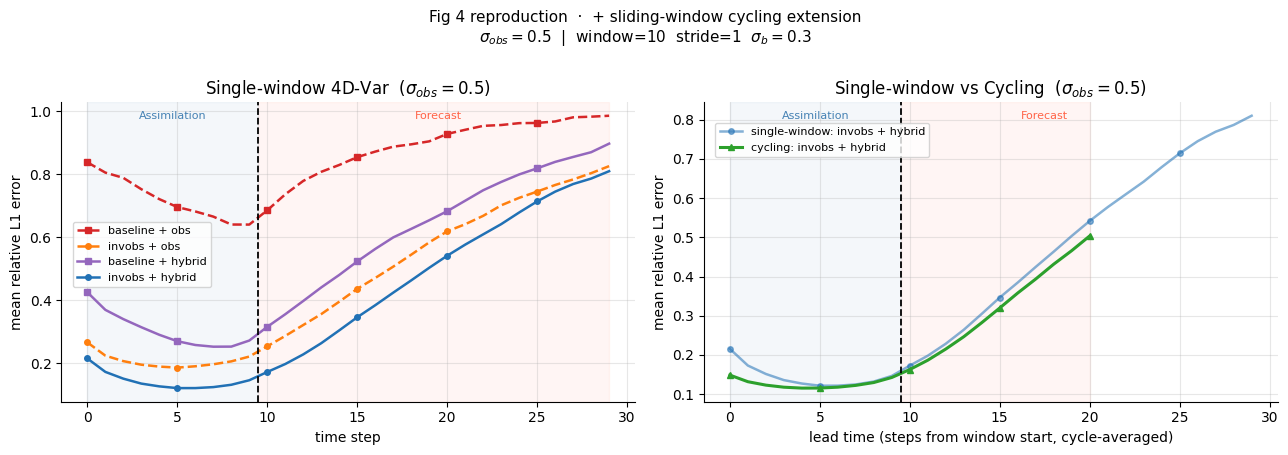

In [21]:
# --- Fig 4 extension: Exp A best combo vs cycling, at σ=0.5 ---
SIGMA_PLOT = 0.5
#SIGMA_PLOT = SIGMA_OBS_SW   # 0.5

combo_styles = {
    'baseline + obs':    {'color': '#d62728', 'linestyle': '--', 'marker': 's'},
    'invobs + obs':      {'color': '#ff7f0e', 'linestyle': '--', 'marker': 'o'},
    'baseline + hybrid': {'color': '#9467bd', 'linestyle': '-',  'marker': 's'},
    'invobs + hybrid':   {'color': '#2171b5', 'linestyle': '-',  'marker': 'o'},
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Left: Exp A panel at σ=0.5 ───────────────────────────────────────────────
ax = axes[0]
X0_gt   = expA_truth[SIGMA_PLOT]
X_truth = L96.integrate(X0_gt, T_TOTAL_A)

for name in combos_expA:
    s = combo_styles[name]
    X_pred = L96.integrate(expA_xrec[SIGMA_PLOT][name], T_TOTAL_A)
    l1_t   = (X_pred - X_truth).abs().mean(dim=-1).mean(dim=-1).detach().cpu().numpy()
    l1_t   = l1_t / gamma
    ax.plot(l1_t, label=name,
            color=s['color'], linestyle=s['linestyle'],
            marker=s['marker'], markersize=4, markevery=5, lw=1.8)

sep = T_EVAL - 0.5
ax.axvline(sep, color='k', lw=1.3, ls='--')
ax.axvspan(0,   sep,            alpha=0.06, color='steelblue')
ax.axvspan(sep, T_TOTAL_A - 1,  alpha=0.06, color='tomato')
ax.text(sep * 0.5,              0.97, 'Assimilation',
        transform=ax.get_xaxis_transform(), fontsize=8,
        ha='center', color='steelblue', va='top')
ax.text(sep + T_FORECAST_A*0.5, 0.97, 'Forecast',
        transform=ax.get_xaxis_transform(), fontsize=8,
        ha='center', color='tomato', va='top')
ax.set_title(f'Single-window 4D-Var  ($\\sigma_{{obs}}={SIGMA_PLOT}$)')
ax.set_xlabel('time step')
ax.set_ylabel('mean relative L1 error')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(0.01, 0.62))
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# ── Right: best single-window (invobs+hybrid) vs cycling ─────────────────────
ax2 = axes[1]

X_pred_best = L96.integrate(expA_xrec[SIGMA_PLOT]['invobs + hybrid'], T_TOTAL_A)
l1_best     = (X_pred_best - X_truth).abs().mean(dim=-1).mean(dim=-1).detach().cpu().numpy()
l1_best     = l1_best / gamma
ax2.plot(l1_best, label='single-window: invobs + hybrid',
         color=combo_styles['invobs + hybrid']['color'],
         linestyle='-', marker='o', markersize=4, markevery=5, lw=1.8, alpha=0.55)

# Cycling: mean L1 vs lead time, averaged over all cycles
starts_sw = sw_result['starts']
T_FC_SW   = T_FORECAST_A

l1_matrix = []
for j, start in enumerate(starts_sw):
    x0_j     = sw_result['analyses'][:, j, :]
    n_fwd    = min(T_FC_SW + 1, T_TOTAL_SW - start)
    X_pred_j = L96.integrate(x0_j, n_fwd)
    X_true_j = X_true_sw[:, start:start+n_fwd].permute(1, 0, 2)
    l1_j     = (X_pred_j - X_true_j).abs().mean(dim=-1).mean(dim=-1).detach().cpu().numpy()
    l1_matrix.append(l1_j)

max_lead  = max(len(v) for v in l1_matrix)
l1_padded = np.full((len(l1_matrix), max_lead), np.nan)
for i, v in enumerate(l1_matrix):
    l1_padded[i, :len(v)] = v
l1_mean_sw = np.nanmean(l1_padded, axis=0) / gamma

ax2.plot(l1_mean_sw, label='cycling: invobs + hybrid',
         color='#2ca02c', linestyle='-', marker='^',
         markersize=4, markevery=5, lw=2.2)

sep2 = WINDOW_T_SW - 0.5
ax2.axvline(sep2, color='k', lw=1.3, ls='--')
ax2.axvspan(0,    sep2,          alpha=0.06, color='steelblue')
ax2.axvspan(sep2, max_lead - 1,  alpha=0.06, color='tomato')
ax2.text(sep2 * 0.5,             0.97, 'Assimilation',
         transform=ax2.get_xaxis_transform(), fontsize=8,
         ha='center', color='steelblue', va='top')
ax2.text(sep2 + T_FC_SW * 0.4,  0.97, 'Forecast',
         transform=ax2.get_xaxis_transform(), fontsize=8,
         ha='center', color='tomato', va='top')
ax2.set_title(f'Single-window vs Cycling  ($\\sigma_{{obs}}={SIGMA_PLOT}$)')
ax2.set_xlabel('lead time (steps from window start, cycle-averaged)')
ax2.set_ylabel('mean relative L1 error')
ax2.legend(fontsize=8, loc='upper left', bbox_to_anchor=(0.01, 0.95))
ax2.grid(alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    'Fig 4 reproduction  ·  + sliding-window cycling extension\n'
    f'$\\sigma_{{obs}}={SIGMA_PLOT}$  |  window={WINDOW_T_SW}  '
    f'stride={STRIDE_SW}  $\\sigma_b={SIGMA_B_SW}$',
    y=1.00, fontsize=11
)
plt.subplots_adjust(top=0.82)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/l96_expA_plus_cycling.png', dpi=150, bbox_inches='tight')
plt.show()

**RMSE Vs Cycle**

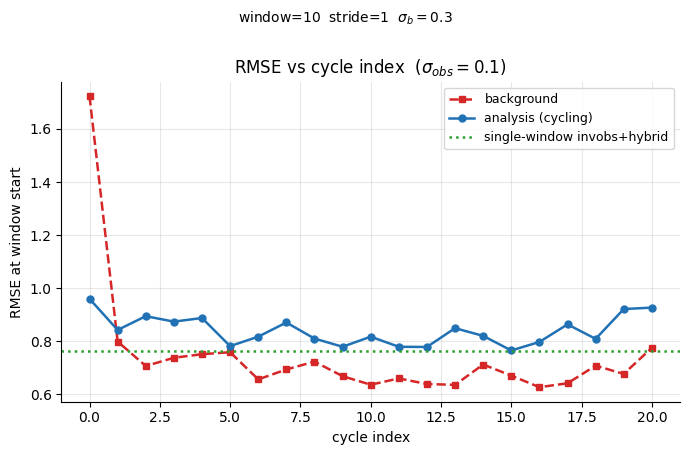

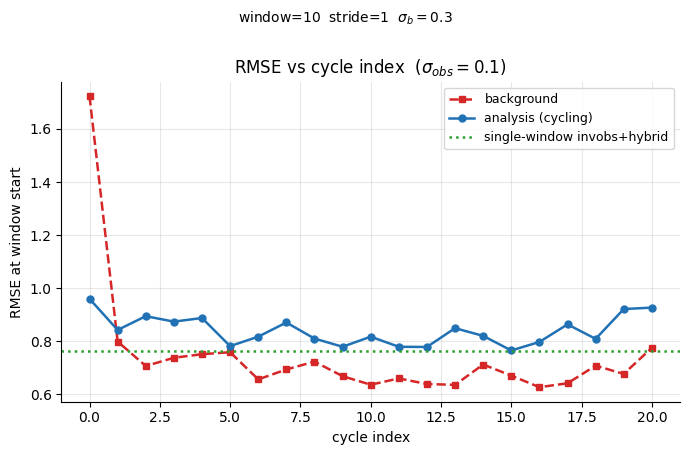

In [27]:
# --- RMSE vs cycle index for current SIGMA_OBS_SW ---
fig, ax = plt.subplots(figsize=(7, 4.5))

inv_sigma = inverters_by_noise[SIGMA_OBS_SW]
analyses    = sw_result['analyses']     # (N, n_cycles, grid)
backgrounds = sw_result['backgrounds']  # (N, n_cycles, grid) — use this directly
starts      = sw_result['starts']
n_cycles    = analyses.shape[1]

background_rmse = []
analysis_rmse   = []

for j, start in enumerate(starts):
    truth_j = X_true_sw[:, start, :]

    xa_j   = analyses[:, j, :]
    xb_j   = backgrounds[:, j, :]

    rmse_a = ((xa_j - truth_j) ** 2).mean(dim=-1).sqrt().mean().item()
    rmse_b = ((xb_j - truth_j) ** 2).mean(dim=-1).sqrt().mean().item()

    analysis_rmse.append(rmse_a)
    background_rmse.append(rmse_b)

cycle_idx = list(range(n_cycles))

ax.plot(cycle_idx, background_rmse,
        color='#d62728', linestyle='--', marker='s',
        markersize=5, lw=1.8, label='background')
ax.plot(cycle_idx, analysis_rmse,
        color='#2171b5', linestyle='-', marker='o',
        markersize=5, lw=1.8, label='analysis (cycling)')

# Single-window reference — use seed=777 to match X_true_sw
N_sw = analyses.shape[0]
_, _, Y_ref, _ = generate_data(L96, n_samples=N_sw, n_time_steps=WINDOW_T_SW,
                                n_warmup=500, obs_noise_std=SIGMA_OBS_SW, seed=777)
X0_sw_ref, _ = run_da(L96, inv_sigma, corr,
                       inv_sigma(Y_ref).detach()[:, 0], Y_ref,
                       T=WINDOW_T_SW, physics_steps=100, obs_steps=400)
rmse_sw = ((X0_sw_ref - X_true_sw[:N_sw, 0, :]) ** 2).mean(dim=-1).sqrt().mean().item()
ax.axhline(rmse_sw, color='#2ca02c', linestyle=':', lw=1.8,
           label='single-window invobs+hybrid')

ax.set_title(f'RMSE vs cycle index  ($\\sigma_{{obs}}={SIGMA_OBS_SW}$)')
ax.set_xlabel('cycle index')
ax.set_ylabel('RMSE at window start')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    f'window={WINDOW_T_SW}  stride={STRIDE_SW}  $\\sigma_b={SIGMA_B_SW}$',
    y=1.00, fontsize=10
)
plt.subplots_adjust(top=0.88)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig(f'figures/l96_rmse_vs_cycle_sigma{SIGMA_OBS_SW}.png', dpi=150, bbox_inches='tight')
plt.show()